# Escalado
Conjunto de datos: iris (incluido en sklearn)
Este conjunto de datos es compacto y perfecto para demostrar técnicas de escalado.

In [1]:
# Importar librerías necesarias
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Cargar el conjunto de datos
iris = load_iris(as_frame=True)
data = iris.data

In [3]:
# Visualizar las estadísticas iniciales
print("Estadísticas iniciales:")
data.describe()

Estadísticas iniciales:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Aplicar MinMaxScaler
minmax_scaler = MinMaxScaler()
data_minmax = pd.DataFrame(minmax_scaler.fit_transform(data), columns=data.columns)

In [5]:
# Aplicar StandardScaler
standard_scaler = StandardScaler()
data_standard = pd.DataFrame(standard_scaler.fit_transform(data), columns=data.columns)

In [6]:
data_standard.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-1.87,-2.43,-1.57,-1.45
25%,-0.90,-0.59,-1.23,-1.18
50%,-0.05,-0.13,0.34,0.13
75%,0.67,0.56,0.76,0.79
max,2.49,3.09,1.79,1.71


# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre las estadísticas originales y las del escalado MinMax?


In [8]:
# Creamos un resumen comparativo de una sola columna (ej. Sepal Length) para mayor claridad
comparativa = pd.DataFrame({
    'Original (cm)': data['sepal length (cm)'].describe(),
    'MinMax (Escalado)': data_minmax['sepal length (cm)'].describe()
})

print("Comparativa de Estadísticas: Original vs MinMaxScaler")
comparativa.round(4)

Comparativa de Estadísticas: Original vs MinMaxScaler


,Original (cm),MinMax (Escalado)
count,150.0000,150.0000
mean,5.8433,0.4287
std,0.8281,0.2300
min,4.3000,0.0000
25%,5.1000,0.2222
50%,5.8000,0.4167
75%,6.4000,0.5833
max,7.9000,1.0000


### 2. Crea una gráfica de la distribución de la variable 'sepal length (cm)' antes y después del escalado.

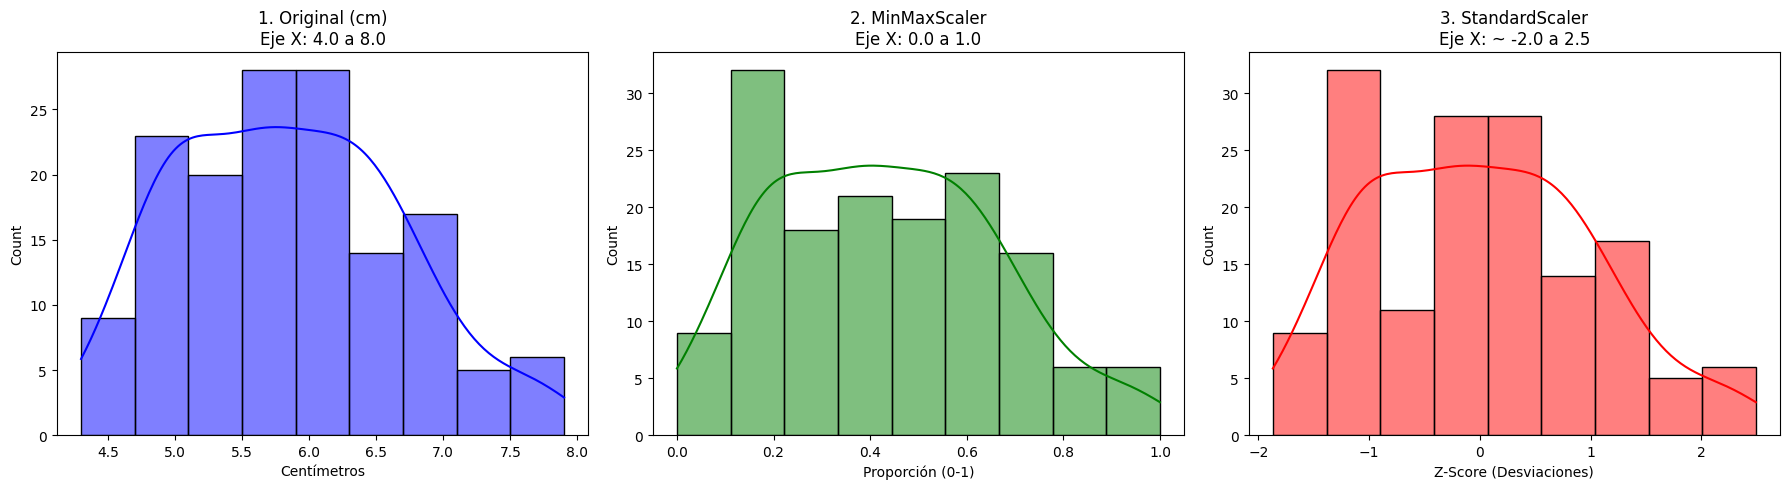

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el lienzo con 3 subgráficas (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. DISTRIBUCIÓN ORIGINAL
sns.histplot(data['sepal length (cm)'], kde=True, color='blue', ax=axes[0])
axes[0].set_title("1. Original (cm)\nEje X: 4.0 a 8.0")
axes[0].set_xlabel("Centímetros")

# 2. DISTRIBUCIÓN MIN-MAX
sns.histplot(data_minmax['sepal length (cm)'], kde=True, color='green', ax=axes[1])
axes[1].set_title("2. MinMaxScaler\nEje X: 0.0 a 1.0")
axes[1].set_xlabel("Proporción (0-1)")

# 3. DISTRIBUCIÓN STANDARD
sns.histplot(data_standard['sepal length (cm)'], kde=True, color='red', ax=axes[2])
axes[2].set_title("3. StandardScaler\nEje X: ~ -2.0 a 2.5")
axes[2].set_xlabel("Z-Score (Desviaciones)")

plt.tight_layout()
plt.show()

### 3. Crea una gráfica de dispersión entre 'sepal length (cm)' y 'sepal width (cm)' con los datos escalados por StandardScaler.

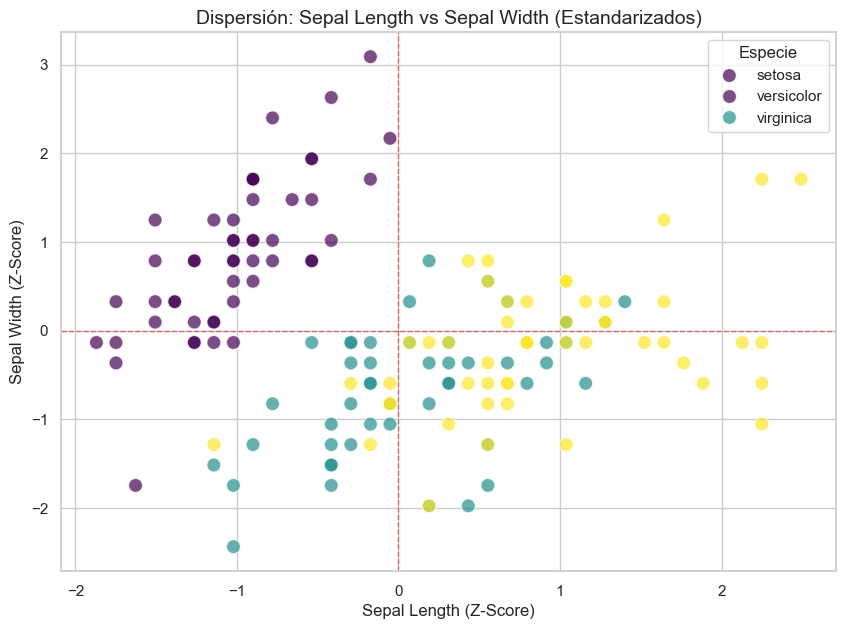

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración del estilo
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# Crear el scatter plot
# Usamos data_standard que creamos en la celda anterior
sns.scatterplot(
    data=data_standard, 
    x='sepal length (cm)', 
    y='sepal width (cm)',
    hue=iris.target,      # Colorear por especie (0, 1, 2)
    palette='viridis',
    s=100,                # Tamaño de los puntos
    alpha=0.7             # Transparencia
)

# Dibujar líneas de referencia en el origen (0,0)
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Personalización de etiquetas
plt.title("Dispersión: Sepal Length vs Sepal Width (Estandarizados)", fontsize=14)
plt.xlabel("Sepal Length (Z-Score)", fontsize=12)
plt.ylabel("Sepal Width (Z-Score)", fontsize=12)
plt.legend(title='Especie', labels=iris.target_names)

plt.show()

### 4. ¿Qué técnica de escalado crees que es más adecuada para este conjunto de datos? ¿Por qué?

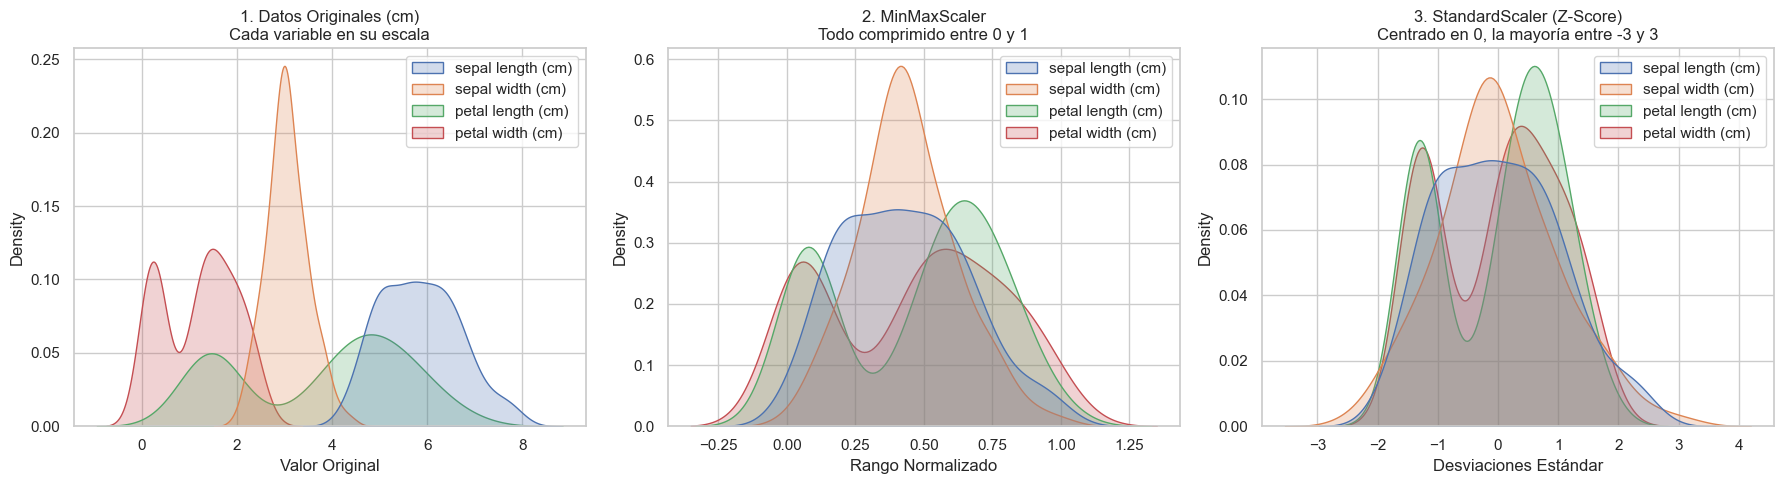

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el lienzo con 3 subgráficas
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. DATOS ORIGINALES (En centímetros)
sns.kdeplot(data=data, ax=ax1, fill=True)
ax1.set_title("1. Datos Originales (cm)\nCada variable en su escala")
ax1.set_xlabel("Valor Original")

# 2. MIN-MAX SCALER (Rango 0-1)
sns.kdeplot(data=data_minmax, ax=ax2, fill=True)
ax2.set_title("2. MinMaxScaler\nTodo comprimido entre 0 y 1")
ax2.set_xlabel("Rango Normalizado")

# 3. STANDARD SCALER (Media 0, Std 1)
sns.kdeplot(data=data_standard, ax=ax3, fill=True)
ax3.set_title("3. StandardScaler (Z-Score)\nCentrado en 0, la mayoría entre -3 y 3")
ax3.set_xlabel("Desviaciones Estándar")

plt.tight_layout()
plt.show()